# V2: 04 — Train → Predict → Evaluate

## Goal
Train LightGBM and XGBoost on V2 features → evaluate on val → evaluate on frozen TEST.

**This notebook is a pure orchestrator — all logic lives in `src/pipeline_evaluate.py`.**

## Inputs
```
outputs/preproc/X_train_lgbm.parquet   — label-encoded train
outputs/preproc/X_val_lgbm.parquet     — label-encoded val
outputs/preproc/X_test_lgbm.parquet    — label-encoded frozen TEST
outputs/preproc/y_train.parquet        — train target
outputs/preproc/y_val.parquet          — val target
outputs/preproc/y_test.parquet         — frozen TEST target
outputs/best_params_lgbm.json          — Optuna best params for LightGBM
outputs/best_params_xgb.json           — Optuna best params for XGBoost
```

## Outputs
```
outputs/models/model_lgbm.pkl          — trained LightGBM model
outputs/models/model_xgb.pkl           — trained XGBoost model
```

##  Statistical Baseline (reference)
```
PR AUC = 0.035 (predict all legitimate)
```

## Step 1 — Imports & Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Notebook lives in v2/ — go one level up to reach project root
PROJECT_ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
for subdir in ['', 'src', 'v0']:
    p = os.path.join(PROJECT_ROOT_PATH, subdir)
    if p not in sys.path:
        sys.path.insert(0, p)

from config import PROJECT_ROOT, PREPROC_DIR, OUTPUTS_DIR
from pipeline_evaluate import (
    load_splits,
    print_flags_summary,
    train_lgbm_model,
    train_xgb_model,
    evaluate_model,
    build_ensemble,
    run_test_evaluation,
)

MODELS_DIR = OUTPUTS_DIR / 'models'

# Statistical baseline — predict all legitimate
STAT_BASELINE_PR = 0.035

print(f'Project root : {PROJECT_ROOT}')
print(f'Preproc dir  : {PREPROC_DIR}')
print(f'Models dir   : {MODELS_DIR}')

Project root : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection
Preproc dir  : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\preproc
Models dir   : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models


## Step 2 — Execution Flags

- `RETRAIN = True`  → always retrain + save (overwrites existing model)
- `RETRAIN = False` → auto-check: if saved model exists → load; else → train + save

In [2]:
RETRAIN_LGBM = False
RETRAIN_XGB  = False

PARAM_FILES = {
    'lgbm': OUTPUTS_DIR / 'best_params_lgbm.json',
    'xgb' : OUTPUTS_DIR / 'best_params_xgb.json',
}
MODEL_FILES = {
    'lgbm': MODELS_DIR / 'model_lgbm.pkl',
    'xgb' : MODELS_DIR / 'model_xgb.pkl',
}

print_flags_summary(RETRAIN_LGBM, RETRAIN_XGB, PARAM_FILES, MODEL_FILES)

EXECUTION FLAGS
  Model     JSON params    Saved model   Action
  ────────────────────────────────────────────────────────
  lgbm          True           True      load saved model
  xgb           True           True      load saved model


## Step 3 — Load Preprocessed Splits

In [3]:
X_train_lgbm, X_val_lgbm, X_test_lgbm, encoding_map, y_train, y_val, y_test = load_splits(PREPROC_DIR)

STEP 1 — Load preprocessed splits
   X_train_lgbm : (354324, 460)  | fraud rate: 3.3833%
   X_val_lgbm   : (118108, 460)    | fraud rate: 3.9041%  (early stopping)
   X_test_lgbm  : (118108, 460)   | fraud rate: 3.4409%  (frozen TEST)
   encoding_map : 32 encoders


## Step 4 — LightGBM

In [4]:
import pickle

if RETRAIN_LGBM or not MODEL_FILES['lgbm'].exists():
    model_lgbm, y_pred_lgbm = train_lgbm_model(
        X_train_lgbm, y_train,
        X_val_lgbm,   y_val,
        models_dir  = MODELS_DIR,
        params_path = str(PARAM_FILES['lgbm']),
    )
else:
    with open(MODEL_FILES['lgbm'], 'rb') as f:
        model_lgbm = pickle.load(f)
    y_pred_lgbm = model_lgbm.predict_proba(X_val_lgbm)[:, 1].astype('float32')
    print(f'Loaded model_lgbm <- {MODEL_FILES["lgbm"]}')

Loaded model_lgbm <- C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models\model_lgbm.pkl


  Model                 ROC AUC    PR AUC
  statistical baseline        —    0.0350
  LightGBM Optuna        0.9327    0.6281   Δ PR=+0.5931


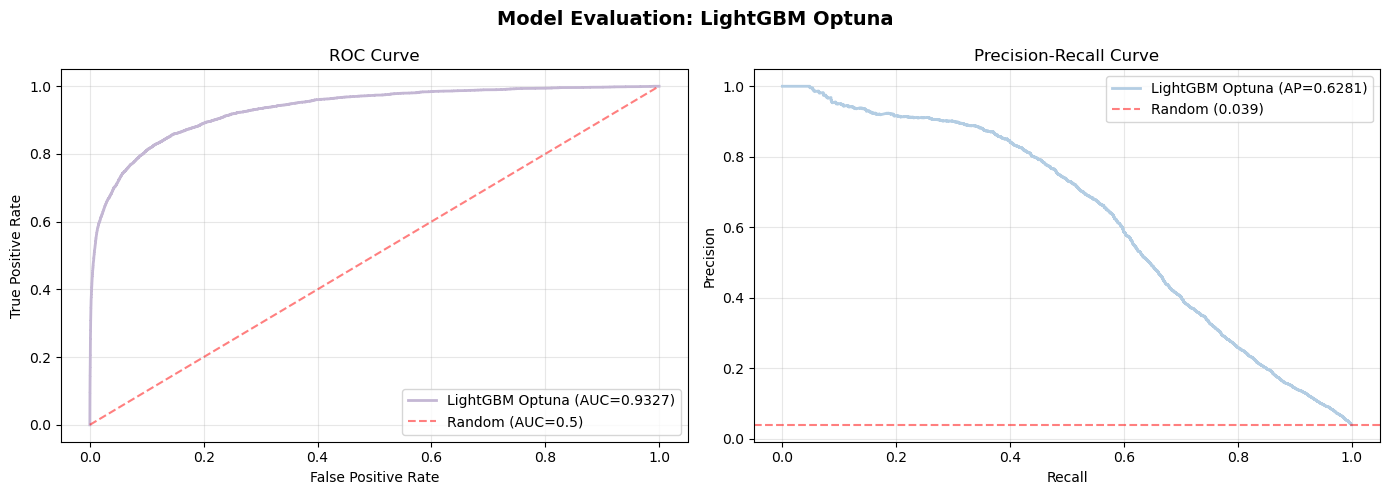

>> Top 30 features by importance:
     1. card1                           importance: 14471
     2. tx_day                          importance: 12560
     3. card2                           importance: 11540
     4. amt_vs_product_median           importance: 11205
     5. TransactionAmt                  importance: 9562
     6. addr1                           importance: 9189
     7. tx_dom                          importance: 8249
     8. tx_amt_mean                     importance: 6836
     9. hour_vs_typical                 importance: 6500
    10. tx_amt_max                      importance: 6425
    11. tx_amt_std                      importance: 6393
    12. tx_hour                         importance: 6267
    13. time_since_last_tx              importance: 6025
    14. delta_amt                       importance: 5714
    15. tx_amt_min                      importance: 5544
    16. amt_vs_personal_median          importance: 5496
    17. amt_z_score                     importance

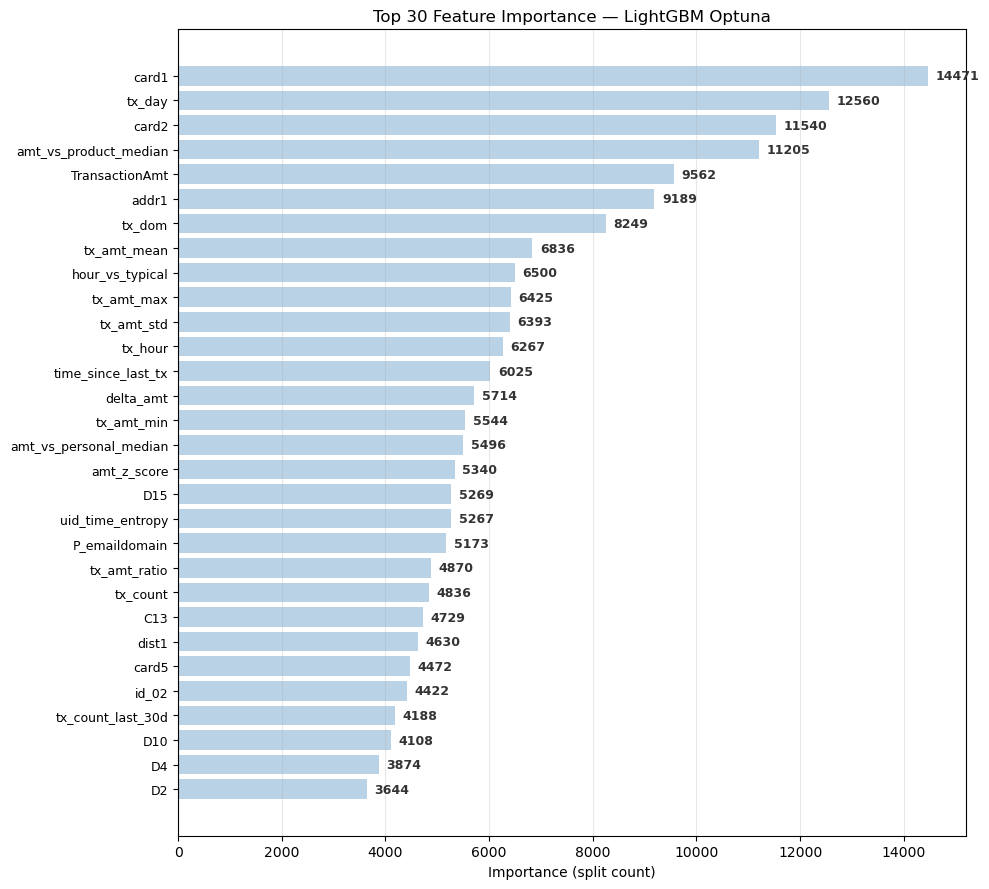

In [5]:
lgbm_roc, lgbm_pr = evaluate_model(
    y_val, y_pred_lgbm,
    model_name    = 'LightGBM Optuna',
    v0_roc     = None,
    v0_pr      = STAT_BASELINE_PR,
    model         = model_lgbm,
    feature_names = X_val_lgbm.columns.tolist(),
    show_plot     = True,
)



## Step 5 — XGBoost

In [6]:
import xgboost as xgb_lib

if RETRAIN_XGB or not MODEL_FILES['xgb'].exists():
    model_xgb, y_pred_xgb = train_xgb_model(
        X_train_lgbm, y_train,
        X_val_lgbm,   y_val,
        models_dir  = MODELS_DIR,
        params_path = str(PARAM_FILES['xgb']),
    )
else:
    with open(MODEL_FILES['xgb'], 'rb') as f:
        model_xgb = pickle.load(f)
    dval        = xgb_lib.DMatrix(X_val_lgbm)
    y_pred_xgb  = model_xgb.predict(
        dval, iteration_range=(0, model_xgb.best_iteration + 1)
    ).astype('float32')
    print(f'Loaded model_xgb <- {MODEL_FILES["xgb"]}')

Loaded model_xgb <- C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models\model_xgb.pkl


  Model                 ROC AUC    PR AUC
  statistical baseline        —    0.0350
  XGBoost Optuna         0.9304    0.6052   Δ PR=+0.5702


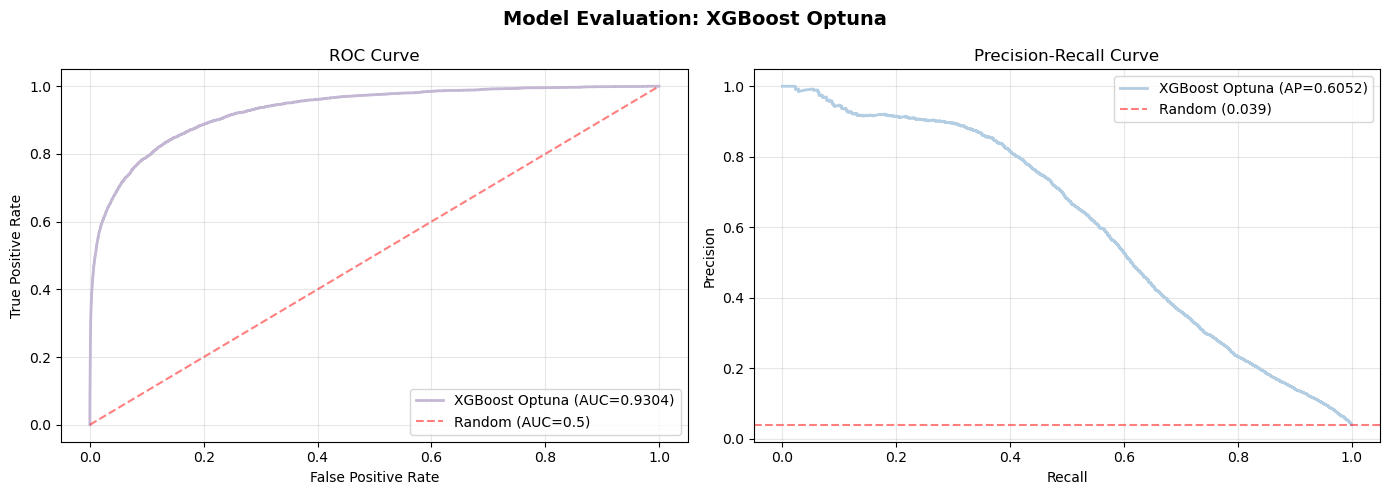

>> Top 30 features by importance:
     1. V258                            importance: 4763.9384765625
     2. V257                            importance: 3038.832763671875
     3. V70                             importance: 2228.4599609375
     4. V201                            importance: 1669.3642578125
     5. V69                             importance: 1377.583984375
     6. V218                            importance: 1331.6500244140625
     7. V91                             importance: 1238.3896484375
     8. V295                            importance: 1177.716796875
     9. V219                            importance: 1063.5361328125
    10. V243                            importance: 1054.7662353515625
    11. V246                            importance: 1000.0346069335938
    12. V30                             importance: 944.602783203125
    13. C8                              importance: 908.3480224609375
    14. C4                              importance: 872.214111328125
 

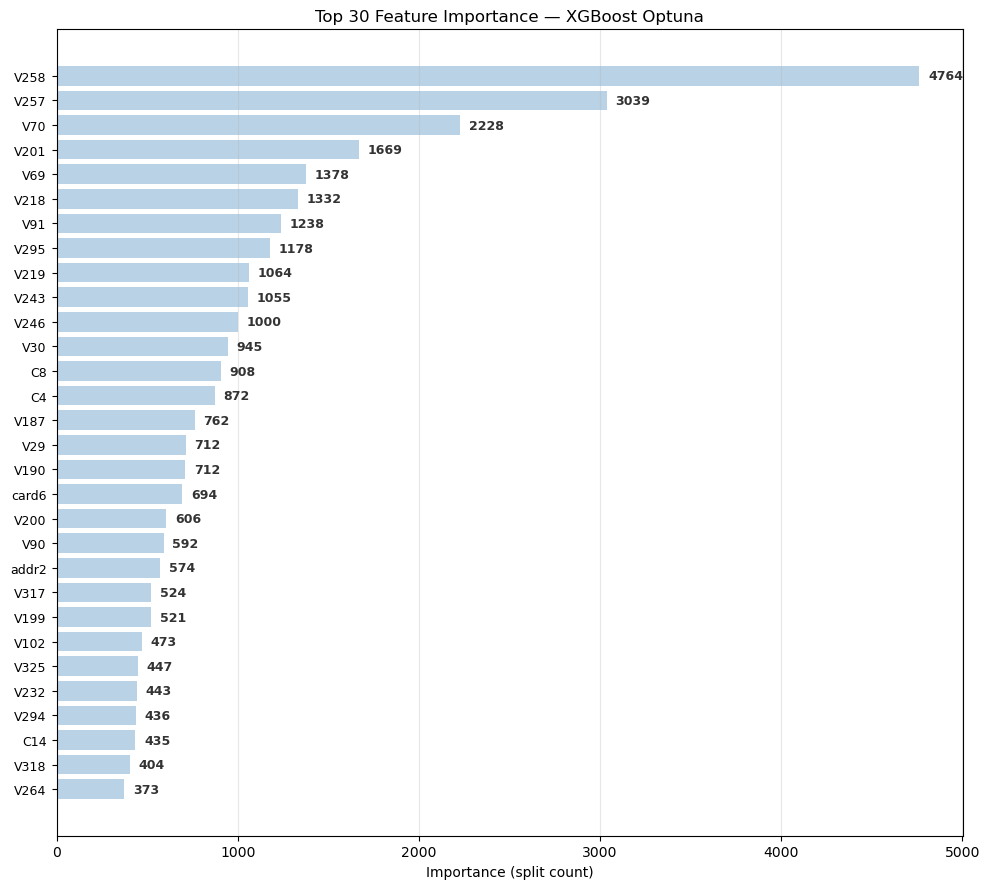

In [7]:
xgb_roc, xgb_pr = evaluate_model(
    y_val, y_pred_xgb,
    model_name    = 'XGBoost Optuna',
    v0_roc        = None,
    v0_pr         = STAT_BASELINE_PR,
    model         = model_xgb,
    feature_names = X_val_lgbm.columns.tolist(),
    show_plot     = True,
)

## Step 6 — Ensemble (LightGBM + XGBoost)

In [8]:
y_pred_ensemble, ensemble_weights = build_ensemble(y_val, y_pred_lgbm, y_pred_xgb)

ENSEMBLE — LightGBM + XGBoost (weighted average)
   Weights : lgbm=0.5006  xgb=0.4994
   Val ROC AUC : 0.9342
   Val PR AUC  : 0.6227


  Model                 ROC AUC    PR AUC
  statistical baseline        —    0.0350
  Ensemble (LGBM+XGB)    0.9342    0.6227   Δ PR=+0.5877


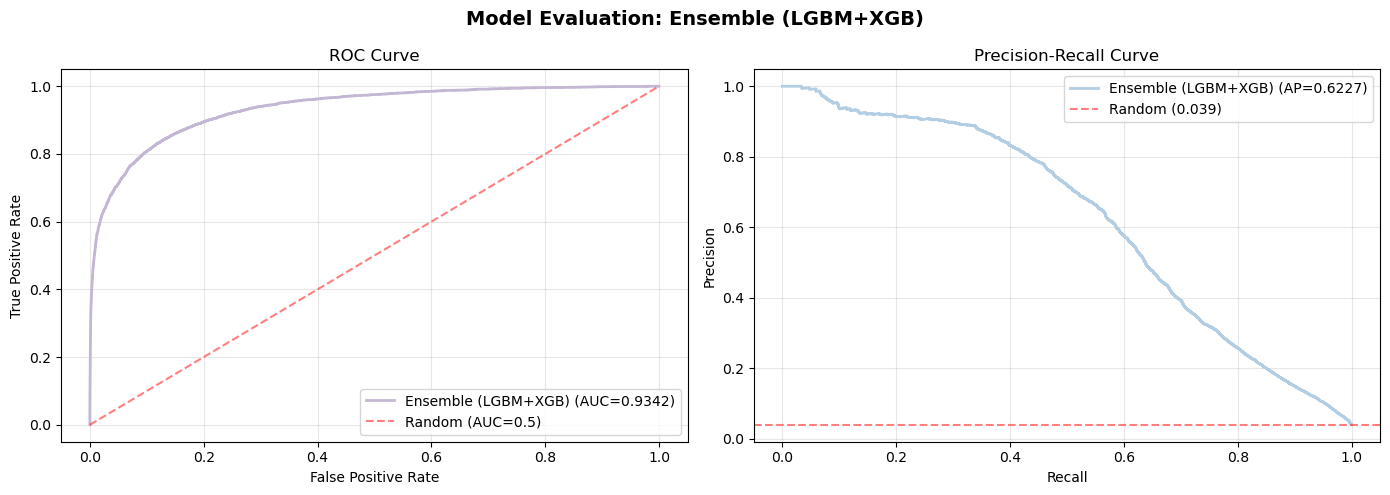

(np.float64(0.9341864734521783), np.float64(0.6226700439200138))

In [9]:
evaluate_model(
    y_val, y_pred_ensemble,
    model_name = 'Ensemble (LGBM+XGB)',
    v0_roc        = None,
    v0_pr         = STAT_BASELINE_PR,
    show_plot  = True,
)

## Step 7 — Frozen TEST Evaluation

> ⚠️ **Run this cell only once — after all model selection decisions are final.**
> The frozen TEST set must never be used for tuning or model selection.

In [10]:
comparison = run_test_evaluation(
    model_files = MODEL_FILES,
    X_test_lgbm = X_test_lgbm,
    y_test      = y_test,
    y_val       = y_val,
    y_pred_lgbm = y_pred_lgbm,
    y_pred_xgb  = y_pred_xgb,
    weights     = ensemble_weights,

    v0_val_roc  = None,
    v0_val_pr   = STAT_BASELINE_PR,
    v0_test_roc = None,
    v0_test_pr  = STAT_BASELINE_PR,
)

FINAL RESULTS — VAL + FROZEN TEST
  Model                   Val ROC   Val PR  Test ROC  Test PR  Δ Test ROC  Δ Test PR
  ───────────────────────────────────────────────────────────────────────
  Statistical Baseline        nan   0.0350       nan   0.0350           —          —
  LightGBM Optuna          0.9327   0.6281    0.8974   0.5087           —    +0.4737
  XGBoost Optuna           0.9304   0.6052    0.8965   0.4977           —    +0.4627
  Ensemble (LGBM+XGB)         nan      nan    0.9002   0.5079           —    +0.4729
